# Notebook 1 — Sequence-to-One with Recurrent Models (ECG5000)

This notebook follows the **7-part recipe card** structure for a **sequence-to-one** task.

We will use **ECG5000**, a small biomedical time-series classification dataset.  
Each sample is **one ECG sequence** and each target is **one class label**.

We will build a recurrent classifier with this flow:

`x  [B, T, F]  ->  [RNN / GRU / LSTM]  ->  h_T  ->  [Linear]  ->  y_hat`

In this notebook:

- **Sequence length**: `T = 140`
- **Features per time step**: `F = 1`
- **Task**: multiclass classification (**sequence-to-one**)
- **Default recurrent backbone**: **GRU**


### as we learned from the lectures, Sequence-to-one with recurrent models;

In a **sequence-to-one** task, the input is an ordered sequence  
`x = (x_1, x_2, ..., x_T)`  
and the goal is to predict **one final output** `y_hat` for the whole sequence.

A recurrent model reads the sequence one time step at a time. At each step, it updates its hidden state:

`h_t = f(h_{t-1}, x_t)`

Here:

- `x_t` = input at time step `t`
- `h_t` = hidden state after seeing input `x_t`
- `h_t` stores a summary of the sequence up to step `t`

After the last element `x_T` is processed, the final hidden state `h_T` acts as a compact summary of the full sequence.  
For sequence-to-one prediction, we use this final summary to produce one output:

`h_T -> [Linear / classifier / regressor] -> y_hat`

So the full flow is:

`sequence -> recurrent updates -> final hidden state h_T -> final prediction y_hat`

In many implementations, the final hidden state `h_T` is directly used as the sequence representation.  
Sometimes this final summary is also called a **context vector** `c`, where often `c = h_T`.



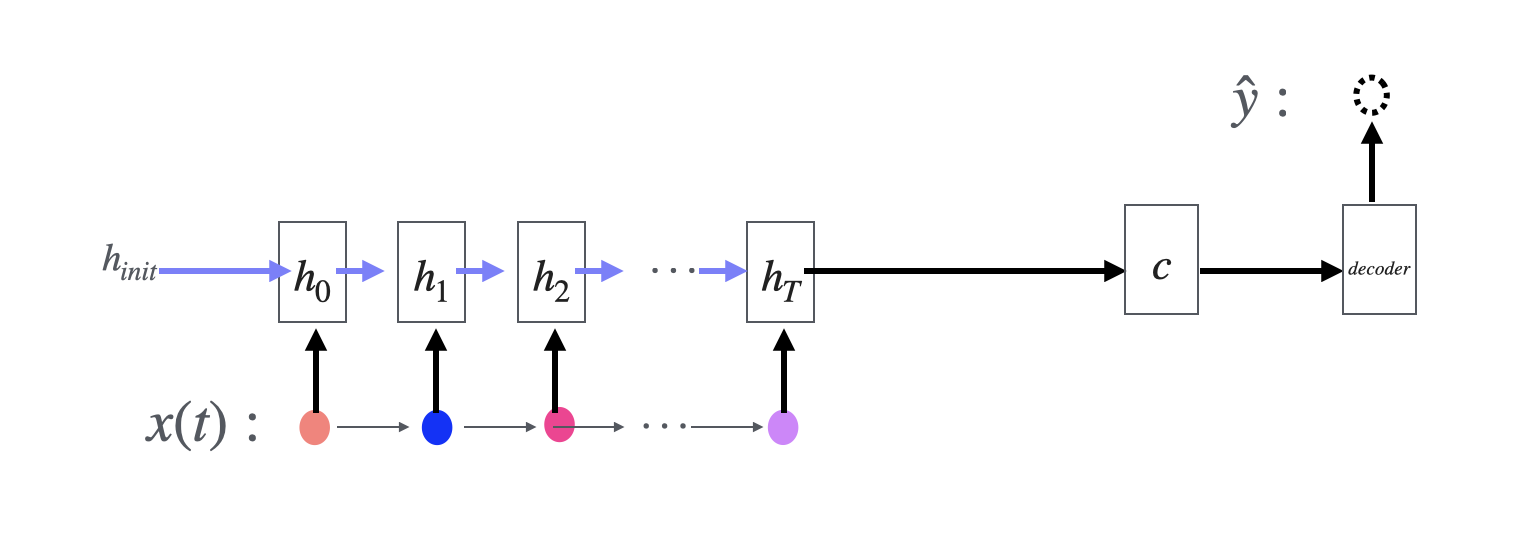


## 1. Load libraries

We only need standard scientific Python + PyTorch.

What we will use:

- `numpy`, `pandas` for loading and shaping the dataset
- `torch` for the model and training
- `matplotlib` for simple plots
- `sklearn` for train/validation split and evaluation utilities


In [1]:

# 1) Basic imports
from pathlib import Path
import urllib.request
import random

# 2) Numerical / data handling
import numpy as np
import pandas as pd

# 3) Plotting
import matplotlib.pyplot as plt

# 4) PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 5) Small utilities for splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# -------------------------------
# Reproducibility + device setup
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda



## 2. Load the sequence dataset

Here **each row is one sequence**.

For ECG5000:

- the **first column** is the class label
- the remaining **140 columns** are the ECG values across time

So after loading:

- raw feature shape: `[N, 140]`
- after reshaping for recurrent models: `[N, T, F] = [N, 140, 1]`

This is exactly the **sequence-to-one** setting:
one input sequence \(x_i\) → one target label \(y_i\).


In [6]:
# Folder where we will keep the raw files
data_dir = Path("data/ecg5000")
data_dir.mkdir(parents=True, exist_ok=True)

# Raw text files from a public GitHub mirror of ECG5000
train_path = data_dir / "ECG5000_TRAIN"
test_path = data_dir / "ECG5000_TEST"

download_urls = {
    "ECG5000_TRAIN": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TRAIN",
    "ECG5000_TEST": "https://raw.githubusercontent.com/tejaslodaya/timeseries-clustering-vae/master/data/ECG5000/ECG5000_TEST",
}

def download_if_needed(path: Path, url: str) -> None:
    """Download one file only if it is not already present."""
    if path.exists():
        print(f"Found existing file: {path}")
        return

    print(f"Downloading {path.name} ...")
    try:
        urllib.request.urlretrieve(url, path)
        print(f"Saved to: {path}")
    except Exception as e:
        raise RuntimeError(
            f"Could not download {path.name}. "
            f"If needed, download it manually and place it at {path}."
        ) from e

download_if_needed(train_path, download_urls["ECG5000_TRAIN"])
download_if_needed(test_path, download_urls["ECG5000_TEST"])

Found existing file: data/ecg5000/ECG5000_TRAIN
Found existing file: data/ecg5000/ECG5000_TEST


In [7]:
# ---------------------------------------
# Load the files:
# - first column = label
# - remaining columns = sequence values
# IMPORTANT: files are comma-separated

train_df = pd.read_csv(train_path, header=None, sep=",")
test_df = pd.read_csv(test_path, header=None, sep=",")

print("Train raw shape:", train_df.shape)
print("Test raw shape: ", test_df.shape)

# Split into labels and sequence values
y_train_raw = train_df.iloc[:, 0].to_numpy()
X_train_raw = train_df.iloc[:, 1:].to_numpy(dtype=np.float32)

y_test_raw = test_df.iloc[:, 0].to_numpy()
X_test_raw = test_df.iloc[:, 1:].to_numpy(dtype=np.float32)

print("X_train_raw:", X_train_raw.shape)
print("y_train_raw:", y_train_raw.shape)
print("X_test_raw: ", X_test_raw.shape)
print("y_test_raw: ", y_test_raw.shape)


Train raw shape: (5000, 141)
Test raw shape:  (4500, 141)
X_train_raw: (5000, 140)
y_train_raw: (5000,)
X_test_raw:  (4500, 140)
y_test_raw:  (4500,)


In [15]:

# Some preproccessing of the data:
# Map labels to 0,1,2,... because PyTorch expects that for CrossEntropyLoss

classes = np.sort(np.unique(np.concatenate([y_train_raw, y_test_raw])))
class_to_idx = {c: i for i, c in enumerate(classes)}

y_train = np.array([class_to_idx[c] for c in y_train_raw], dtype=np.int64)
y_test = np.array([class_to_idx[c] for c in y_test_raw], dtype=np.int64)

print("Original classes:", classes)
print("Mapped classes:  ", np.unique(y_train))



# ----------------------------------------------------
# Normalize the sequence values using train statistics
train_mean = X_train_raw.mean()
train_std = X_train_raw.std() + 1e-8

X_train = (X_train_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

# ----------------------------------------------------
# Recurrent models expect [N, T, F]
# ECG5000 is univariate, so F = 1
# ----------------------------------------------------
X_train = X_train[:, :, None]   # [N, 140, 1]
X_test = X_test[:, :, None]

print("X_train reshaped:", X_train.shape)
print("X_test reshaped: ", X_test.shape)

Original classes: [1 2 3 4 5]
Mapped classes:   [0 1 2 3 4]
X_train reshaped: (5000, 140, 1)
X_test reshaped:  (4500, 140, 1)


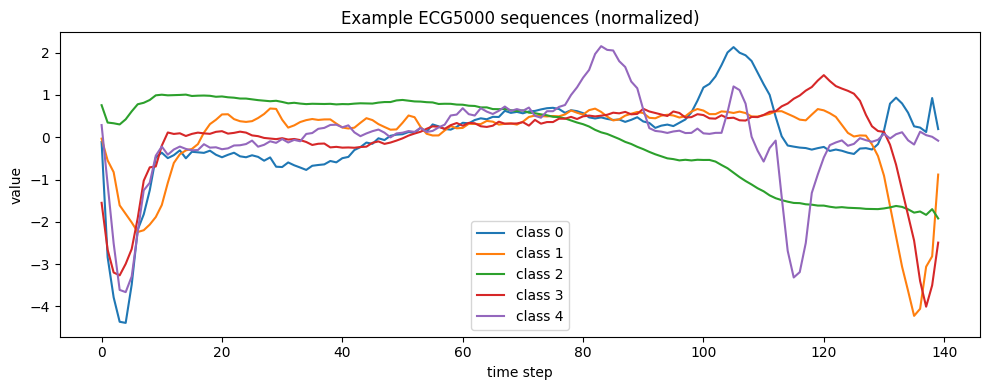

In [18]:
# Quick visual sanity check: plot one example from each of a few classes
plt.figure(figsize=(10, 4))
for i in range(min(5, len(classes))):
    idx = np.where(y_train == i)[0][0]
    plt.plot(X_train[idx, :, 0], label=f"class {i}")

plt.title("Example ECG5000 sequences (normalized)")
plt.xlabel("time step")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# note that the data set was already seperated into train and test, so we did not have to do it manuslly
#So, to summarize, this is our data: 


# for example X_train.shape should be:
# ( {number of sequences in the train dataset} , {sequence length T} ,  {umber of features per time step F, here is 1} )

X_train.shape , y_train.shape , X_test.shape,  y_test.shape



((5000, 140, 1), (5000,), (4500, 140, 1), (4500,))

## 3. Set up the DataLoader

All sequences here have the **same length**, so batching is easy (no padding is required).  
We can stack them directly into tensors with shape `x in [B, T, F]`, where:

- `B` = batch size
- `T` = sequence length
- `F` = number of features per time step

We will also create a **validation split** from the training set.

In [40]:

# ---------------------------------------
# Create a validation split from training
# we use train_test_split from sklearn to do so

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

print("Train split:", X_train_split.shape, y_train_split.shape)
print("Val split:  ", X_val.shape, y_val.shape)
print("Test set:   ", X_test.shape, y_test.shape)


# ---------------------------------------
# Convert everything to PyTorch tensors
X_train_tensor = torch.tensor(X_train_split, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ---------------------------------------
# Wrap in TensorDataset and DataLoader
# for this we use torch TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64 # we here define the batch size, 64 is good  and then use torch DataLoader


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Train split: (4000, 140, 1) (4000,)
Val split:   (1000, 140, 1) (1000,)
Test set:    (4500, 140, 1) (4500,)


In [41]:

# Inspect one batch
x_batch, y_batch = next(iter(train_loader)) # this is how we can acess one batch,  

# Another way to doing next(iter(train_loader)), but more clear!
# for x_batch, y_batch in train_loader:
#     break

print("One batch x shape:", x_batch.shape)  # [B, T, F]
print("One batch y shape:", y_batch.shape)  # [B]

One batch x shape: torch.Size([64, 140, 1])
One batch y shape: torch.Size([64])



## 4. Build the recurrent model

The model has **two parts**:

1. a recurrent **backbone** (`RNN`, `GRU`, or `LSTM`)
2. a **task head** (`Linear`) that maps the final hidden state to class logits

Because this is **sequence-to-one**, we use the **last hidden state**.

Input shape:
`x in [B, T, F]`

Backbone output:
- hidden states across time: `[B, T, H]`
- last hidden state used for prediction: `[B, H]`

where \(H\) is the hidden size.


Note that there is no minGRU implemented in pytorch as an standard model for the recurrent block, we will use GRU but inplemnting minGRU would be fun and easy

In [43]:
class SequenceClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_classes: int,
        model_type: str = "GRU",   # choose from: "RNN", "GRU", "LSTM"
        num_layers: int = 1,
        dropout: float = 0.0,
        bidirectional: bool = False,
    ):
        super().__init__()

        self.model_type = model_type.upper()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Number of directions is 2 for bidirectional models, else 1
        self.num_directions = 2 if bidirectional else 1

        # -------------------------------
        # Choose the recurrent backbone
        if self.model_type == "RNN":
            self.backbone = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                nonlinearity="tanh",
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        elif self.model_type == "GRU":
            self.backbone = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        elif self.model_type == "LSTM":
            self.backbone = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional,
            )
        else:
            raise ValueError("model_type must be one of: 'RNN', 'GRU', 'LSTM'")

        # -------------------------------
        # Task head:
        # maps last hidden state -> logits
        self.classifier = nn.Linear(hidden_size * self.num_directions, num_classes)


    # Now the forward path: order is first the recurrent block then the head.
    def forward(self, x):
        # x shape: [B, T, F]
        # recurrent_out shape: [B, T, H] (or [B, T, 2H] if bidirectional)
        
        if self.model_type == "LSTM": # because LSTM returns both the hidden state h_n and the cell state c_n
            recurrent_out, (h_n, c_n) = self.backbone(x)
        else: 
            recurrent_out, h_n = self.backbone(x) # RNN and gRU just retutn the hidden state h_n, they dont have cell state..

        # -----------------------------------------
        # We use the last time-step output for
        # sequence-to-one classification
        last_hidden = recurrent_out[:, -1, :]   # [B, H] or [B, 2H]

        # Convert last hidden state into class logits
        logits = self.classifier(last_hidden)   # [B, num_classes]
        return logits

In [56]:
# ---------------------------------------
# Instantiate the model

INPUT_SIZE = X_train.shape[2]      #should be 1, because in pur case F = 1
HIDDEN_SIZE = 16 #
NUM_CLASSES = len(classes)
MODEL_TYPE = "GRU"                 # try: "RNN", "GRU", "LSTM"

model = SequenceClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    model_type=MODEL_TYPE,
    num_layers=1,
    dropout=0.0,
    bidirectional=False,
).to(device)

print(model)

# Quick forward-shape check
with torch.no_grad():
    dummy_logits = model(x_batch.to(device))
print("Logits shape:", dummy_logits.shape)  # [B, num_classes]


SequenceClassifier(
  (backbone): GRU(1, 16, batch_first=True)
  (classifier): Linear(in_features=16, out_features=5, bias=True)
)
Logits shape: torch.Size([64, 5])



## 5. Define the loss function

This is a **multiclass classification** task, so we use:

- `CrossEntropyLoss` for the class prediction loss
- `Adam` for optimization

Important:
`CrossEntropyLoss` expects **raw logits** from the model, so we do **not** apply softmax inside the model.


In [57]:
# Loss function: multiclass classification
criterion = nn.CrossEntropyLoss() # becasue we are looking at classes...

#  Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


# Optional: small scheduler (can be skipped if you want the simplest loop...)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="max",     # we monitor validation accuracy
#     factor=0.5,
#     patience=3,
# )

print("Loss:", criterion)
print("Optimizer:", optimizer)


Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)



## 6. Define the train / validation / test functions

For each batch we:

1. move data to device
2. run the forward pass
3. compute the loss
4. backpropagate (for training)
5. update the model
6. track accuracy

Because this is **sequence-to-one**, accuracy is computed at the **sequence level**.


In [58]:
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Compute batch accuracy from class logits."""
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    return correct / targets.size(0)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    for x, y in loader:
        # Move one batch to the selected device
        x = x.to(device)
        y = y.to(device)

        # Standard training step
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        # Gradient clipping is useful for recurrent models
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate metrics
        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += accuracy_from_logits(logits, y) * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples
    return epoch_loss, epoch_acc



@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total_samples = 0

    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += accuracy_from_logits(logits, y) * batch_size
        total_samples += batch_size

        all_preds.append(logits.argmax(dim=1).cpu())
        all_targets.append(y.cpu())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_acc / total_samples
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return epoch_loss, epoch_acc, all_preds, all_targets



## 7. Run training and inspect results

We now train the model, keep the best validation checkpoint, and then evaluate on the test set.

At the end we will inspect:

- training / validation curves
- final test accuracy
- confusion matrix


Epoch 01/30 | train loss: 1.4525 | train acc: 0.5042 | val loss: 1.1820 | val acc: 0.8220
Epoch 02/30 | train loss: 0.8124 | train acc: 0.8775 | val loss: 0.5550 | val acc: 0.8970
Epoch 03/30 | train loss: 0.4941 | train acc: 0.8935 | val loss: 0.4588 | val acc: 0.9010
Epoch 04/30 | train loss: 0.4528 | train acc: 0.8945 | val loss: 0.4362 | val acc: 0.9050
Epoch 05/30 | train loss: 0.4402 | train acc: 0.8952 | val loss: 0.4266 | val acc: 0.9030
Epoch 06/30 | train loss: 0.4315 | train acc: 0.8962 | val loss: 0.4188 | val acc: 0.9030
Epoch 07/30 | train loss: 0.4209 | train acc: 0.8965 | val loss: 0.4125 | val acc: 0.9030
Epoch 08/30 | train loss: 0.4108 | train acc: 0.8985 | val loss: 0.4015 | val acc: 0.9030
Epoch 09/30 | train loss: 0.4019 | train acc: 0.8998 | val loss: 0.3996 | val acc: 0.9010
Epoch 10/30 | train loss: 0.3897 | train acc: 0.9018 | val loss: 0.3960 | val acc: 0.9010
Epoch 11/30 | train loss: 0.3740 | train acc: 0.9058 | val loss: 0.3765 | val acc: 0.9050
Epoch 12/3

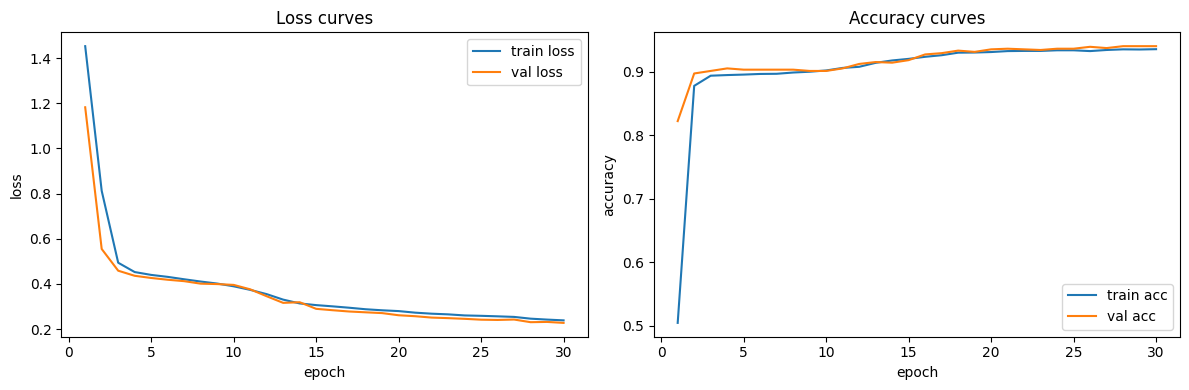

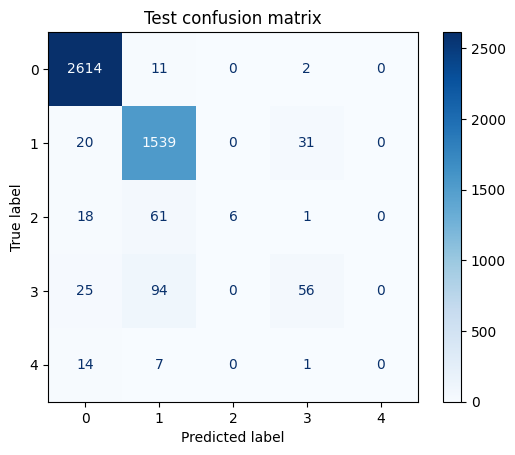

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2627
           1       0.90      0.97      0.93      1590
           2       1.00      0.07      0.13        86
           3       0.62      0.32      0.42       175
           4       0.00      0.00      0.00        22

    accuracy                           0.94      4500
   macro avg       0.70      0.47      0.49      4500
weighted avg       0.93      0.94      0.92      4500



/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [59]:

NUM_EPOCHS = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -float("inf")
best_state_dict = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    # Save the best validation model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

# Load best validation model before testing
model.load_state_dict(best_state_dict)
model.to(device)

test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader, criterion, device)

print("\nBest validation accuracy:", f"{best_val_acc:.4f}")
print("Test loss:", f"{test_loss:.4f}")
print("Test accuracy:", f"{test_acc:.4f}")

# ---------------------------------------
# Plot training / validation curves
# ---------------------------------------
epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy curves")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------
# Confusion matrix on the test set
# ---------------------------------------
cm = confusion_matrix(test_targets, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test confusion matrix")
plt.show()

# ---------------------------------------
# Detailed classification report
# ---------------------------------------
print(classification_report(test_targets, test_preds))
